# 📝 Exercise M5.02

The aim of this exercise is to find out whether a decision tree model is able
to extrapolate.

By extrapolation, we refer to values predicted by a model outside of the range
of feature values seen during the training.

We first load the regression data.

In [1]:
import pandas as pd

penguins = pd.read_csv("../datasets/penguins_regression.csv")

feature_name = "Flipper Length (mm)"
target_name = "Body Mass (g)"
data_train, target_train = penguins[[feature_name]], penguins[target_name]

<div class="admonition note alert alert-info">
<p class="first admonition-title" style="font-weight: bold;">Note</p>
<p class="last">If you want a deeper overview regarding this dataset, you can refer to the
Appendix - Datasets description section at the end of this MOOC.</p>
</div>

First, create two models, a linear regression model and a decision tree
regression model, and fit them on the training data. Limit the depth at 3
levels for the decision tree.

In [2]:
# Write your code here.
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
linear_regressor = LinearRegression()
tree_regressor = DecisionTreeRegressor(max_depth=3, random_state=0)

Create a synthetic dataset containing all possible flipper length from the
minimum to the maximum of the training dataset. Get the predictions of each
model using this dataset.

In [4]:
# Write your code here.
import numpy as np
data_test = pd.DataFrame({feature_name: np.arange(data_train[feature_name].min(), data_train[feature_name].max())})

Create a scatter plot containing the training samples and superimpose the
predictions of both models on the top.

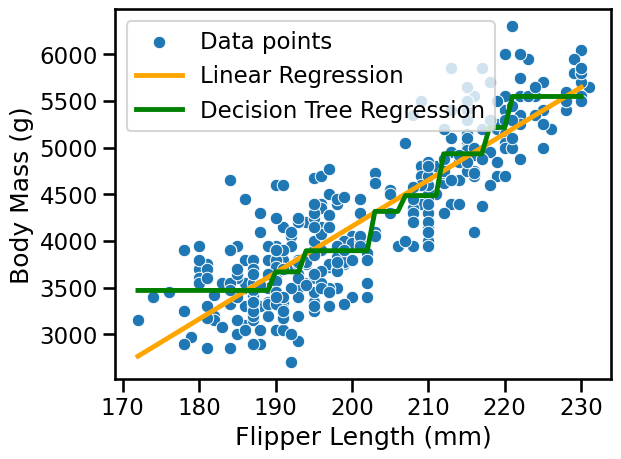

In [9]:
# Write your code here.
import seaborn as sns
import matplotlib.pyplot as plt

linear_regressor.fit(data_train, target_train)
tree_regressor.fit(data_train, target_train)

sns.scatterplot(x=feature_name, y=target_name, data=penguins, label="Data points")
plt.plot(data_test, linear_regressor.predict(data_test), color="orange", label="Linear Regression")
plt.plot(data_test, tree_regressor.predict(data_test), color="green", label="Decision Tree Regression")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.legend()

Now, we check the extrapolation capabilities of each model. Create a dataset
containing a broader range of values than your previous dataset, in other
words, add values below and above the minimum and the maximum of the flipper
length seen during training.

In [10]:
# Write your code here.
data_test = pd.DataFrame({feature_name: np.arange(data_train[feature_name].min()-20, data_train[feature_name].max() +20)})

Finally, make predictions with both models on this new interval of data.
Repeat the plotting of the previous exercise.

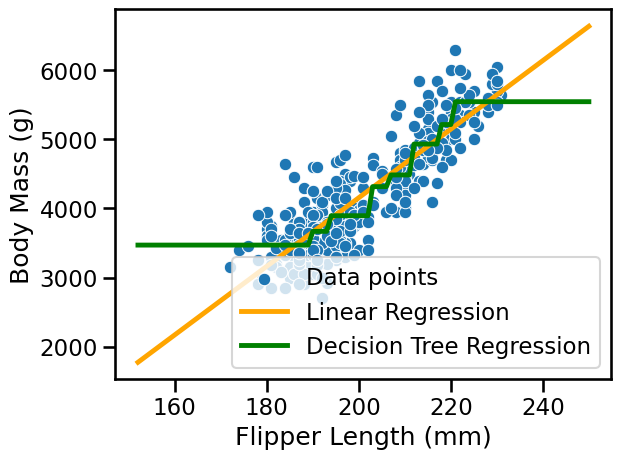

In [11]:
# Write your code here.
sns.scatterplot(x=feature_name, y=target_name, data=penguins, label="Data points")
plt.plot(data_test, linear_regressor.predict(data_test), color="orange", label="Linear Regression")
plt.plot(data_test, tree_regressor.predict(data_test), color="green", label="Decision Tree Regression")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.legend()